# Un mosquito cruzó un océano de ciudades

**126 millones** de africanos que viven en ciudades tienen un vecino nuevo. Llegó del sur de Asia, se adaptó al agua de los tanques urbanos y trae en sus genes la receta para sobrevivir a los insecticidas.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Un equipo secuenció **645 genomas completos** de *Anopheles stephensi* por África, Medio Oriente y Asia para reconstruir de dónde vino y por dónde se está metiendo. Nosotros abrimos su tabla de muestreo —**551 mosquitos** con país, coordenadas y fecha— y reconstruimos la **geografía** de esa invasión.

**Paper:** Dennis et al. (2026), *Science*. [DOI: 10.1126/science.adx6925](https://doi.org/10.1126/science.adx6925)
**Datos:** [Repositorio AsGARD en Zenodo](https://doi.org/10.5281/zenodo.19324618)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-10-stephensi-mosquito-invasor-africa/notebook.ipynb)

## De dónde salió esto

*Anopheles stephensi* no es un mosquito africano. Es asiático, y su superpoder es que cría en agua almacenada —tanques, cisternas, llantas— justo lo que abunda en una ciudad. Por eso preocupa: los mosquitos de malaria clásicos de África viven en el campo; este entra a la ciudad.

El equipo juntó mosquitos de **9 países** (de India y Afganistán hasta Sudán y Yemen) y les leyó el genoma. Nuestra tabla no trae el ADN crudo —eso está embargado— pero sí trae **dónde y cuándo** se capturó cada uno. Con eso se dibuja el mapa de la invasión.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuracion — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Dennis et al. (2026), Science | Datos: AsGARD, Zenodo (551 muestras)'

# Colores por super-poblacion (gradiente origen -> frente africano)
COLOR_ASIA   = '#7C3AED'   # Fuente sudasiatica (violeta = origen)
COLOR_KSAIR  = '#D97706'   # KSA & Iran (amber = intermedio)
COLOR_HORN   = '#DC2626'   # Cuerno de Africa & Yemen (rojo = frente)
COLOR_PUENTE = '#059669'   # Djibouti City (cabeza de puente)

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
df = pd.read_csv('datos/muestras_stephensi.csv')
df['fecha'] = pd.to_datetime(df['collection_date'], format='%d/%m/%Y', errors='coerce')
df['anio'] = df['fecha'].dt.year

# Orden narrativo de las super-poblaciones: origen -> frente
ORDEN_SUPER = ['Asia', 'KSA & Iran', 'Horn of Africa & Yemen']
COLOR_SUPER = {'Asia': COLOR_ASIA, 'KSA & Iran': COLOR_KSAIR,
               'Horn of Africa & Yemen': COLOR_HORN}
ETIQUETA_SUPER = {'Asia': 'Fuente sudasiatica',
                  'KSA & Iran': 'Peninsula (KSA e Iran)',
                  'Horn of Africa & Yemen': 'Frente africano'}

print(f'Muestras en la tabla: {len(df)}')
print(f'Pasaron control de calidad: {int((df.data_qc_pass == 1).sum())}')
print(f'Paises: {df.country.nunique()} | Poblaciones: {df.analysis_pop.nunique()}')
print(f'Rango de fechas: {df.fecha.min().date()} a {df.fecha.max().date()}')
print()
for sp in ORDEN_SUPER:
    n = int((df.SuperPopulation == sp).sum())
    lon = df.loc[df.SuperPopulation == sp, 'longitude'].mean()
    print(f'  {sp:26s} n={n:3d}  centroide {lon:5.1f} grados E')

Muestras en la tabla: 551
Pasaron control de calidad: 475
Paises: 9 | Poblaciones: 11
Rango de fechas: 2005-04-01 a 2023-12-11

  Asia                       n= 58  centroide  72.5 grados E
  KSA & Iran                 n=117  centroide  55.6 grados E
  Horn of Africa & Yemen     n=376  centroide  37.3 grados E


## El mapa

Aquí está.

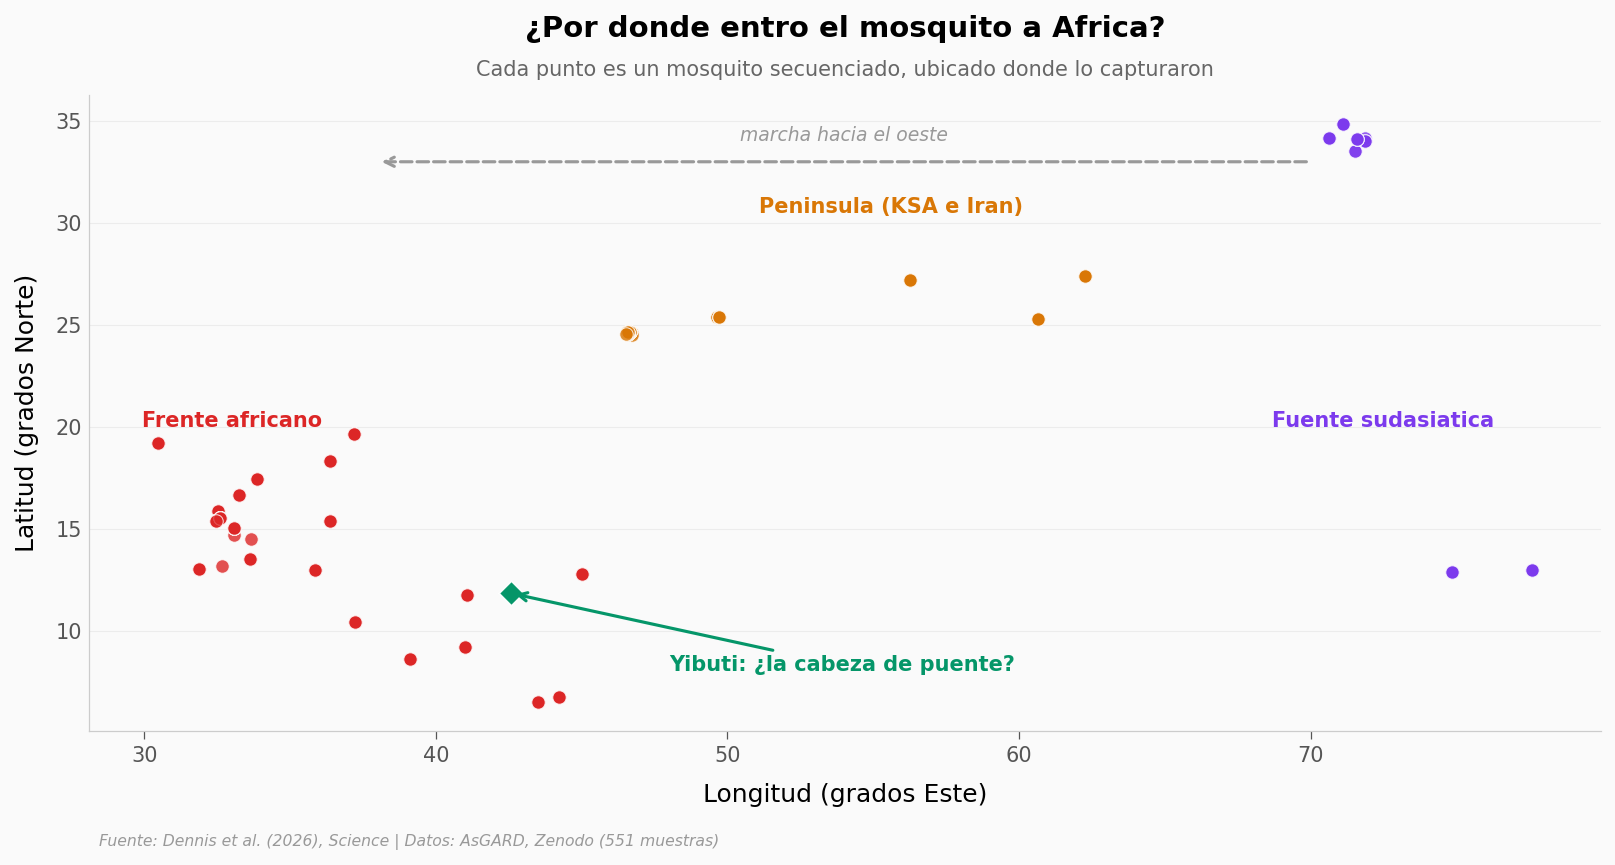

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for sp in ORDEN_SUPER:
    sub = df[df.SuperPopulation == sp]
    ax.scatter(sub['longitude'], sub['latitude'],
               color=COLOR_SUPER[sp], s=42, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=5)

# Etiqueta inline junto al centroide de cada grupo (reemplaza legend box)
posiciones = {
    'Asia': (72.5, 20.0),
    'KSA & Iran': (55.6, 30.5),
    'Horn of Africa & Yemen': (33.0, 20.0),
}
for sp, (lx, ly) in posiciones.items():
    ax.text(lx, ly, ETIQUETA_SUPER[sp], fontsize=10, fontweight='bold',
            color=COLOR_SUPER[sp], ha='center', zorder=6)

# Djibouti City — la cabeza de puente, resaltada aparte
dji = df[df.analysis_pop == 'Djibouti City']
ax.scatter(dji['longitude'], dji['latitude'], color=COLOR_PUENTE,
           s=70, alpha=0.95, edgecolors='white', linewidths=0.8, zorder=7,
           marker='D')
ax.annotate('Yibuti: ¿la cabeza de puente?',
            xy=(dji['longitude'].mean(), dji['latitude'].mean()),
            xytext=(48, 8), fontsize=10, fontweight='bold', color=COLOR_PUENTE,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUENTE, lw=1.5), zorder=8)

# Flecha del sentido de la marcha (este -> oeste), puramente ilustrativa
ax.annotate('', xy=(38, 33), xytext=(70, 33),
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.5, ls='--'))
ax.text(54, 34.0, 'marcha hacia el oeste', fontsize=9, color='#999999',
        ha='center', style='italic')

ax.set_title('¿Por donde entro el mosquito a Africa?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un mosquito secuenciado, ubicado donde lo capturaron',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud (grados Este)')
ax.set_ylabel('Latitud (grados Norte)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_invasion.png', dpi=200, bbox_inches='tight')
plt.show()

Tres bloques, tres momentos de la misma historia. En el extremo derecho, la fuente: mosquitos de India, Pakistán y Afganistán. En el medio, la Península Arábiga e Irán. Y a la izquierda, pegado a África, el frente: Sudán, Etiopía, Yemen.

El diamante verde es Yibuti. Los genomas del paper apuntan a que ese puerto funcionó como **cabeza de puente**: el punto por donde el mosquito asiático saltó al continente y desde donde se abrieron los frentes. Ojo con la palabra: esa ruta es una *reconstrucción* a partir del ADN, no algo que se haya visto pasar. Lo que el mapa muestra sin discusión es dónde está el bicho hoy.

## ¿Dónde se concentró la búsqueda?

El mapa reparte los puntos por geografía. Pero si los contamos por población, aparece otra cosa: no se muestreó parejo.

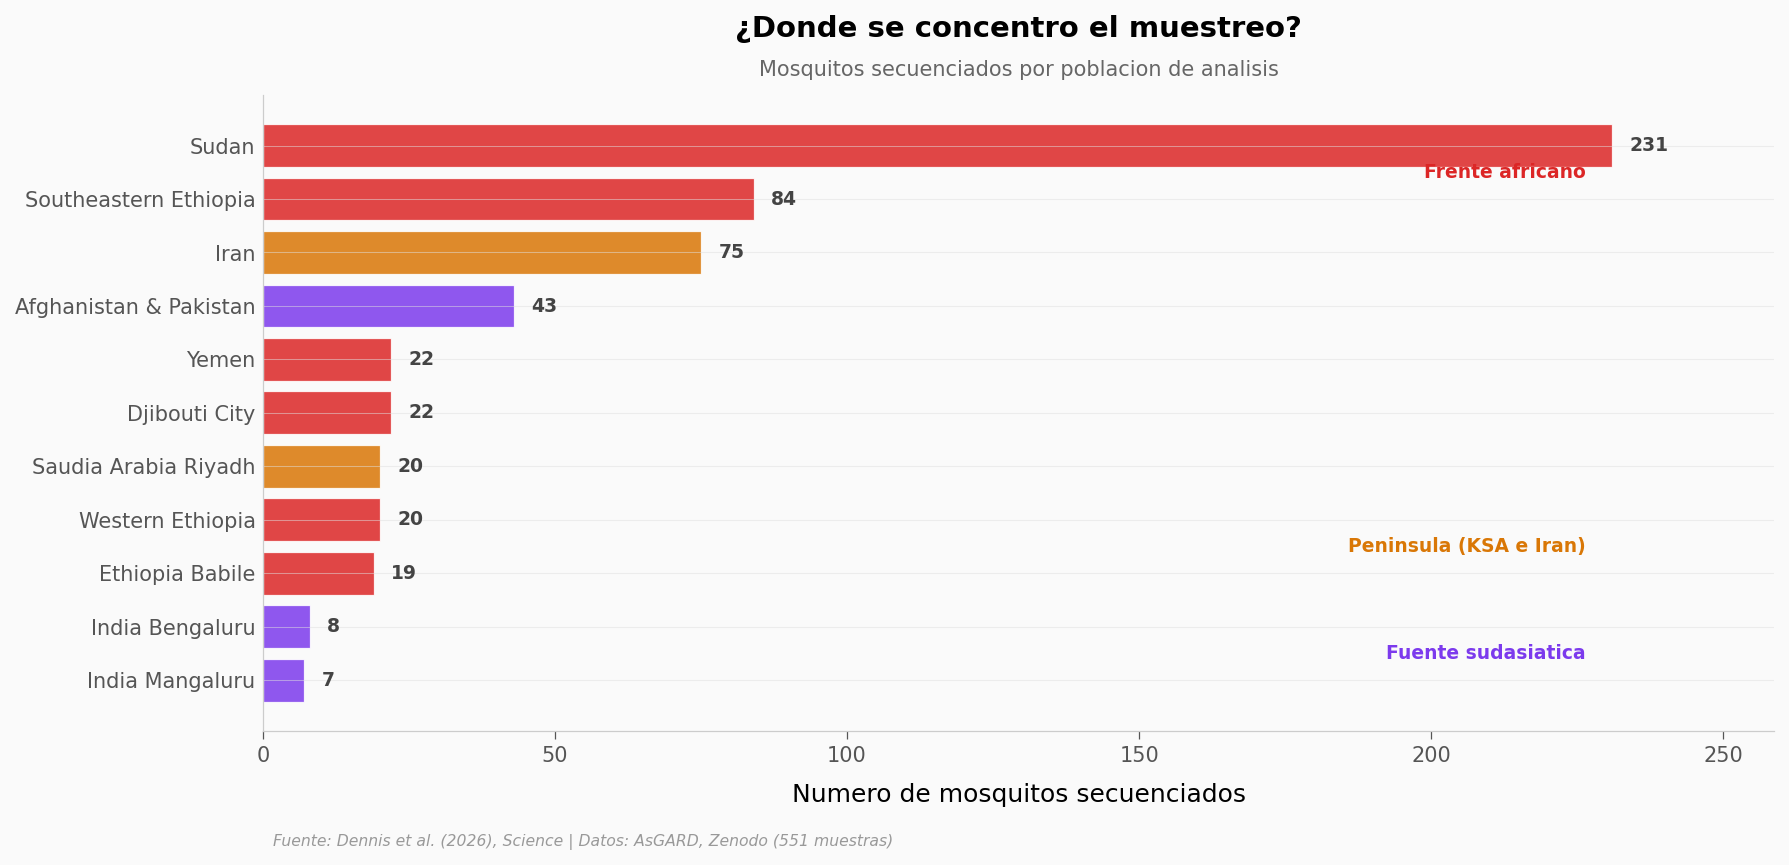

In [3]:
conteo = df['analysis_pop'].value_counts().sort_values()

# Color de cada barra segun su super-poblacion
pop_super = df.drop_duplicates('analysis_pop').set_index('analysis_pop')['SuperPopulation']
colores = [COLOR_SUPER[pop_super[p]] for p in conteo.index]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.barh(conteo.index, conteo.values, color=colores, alpha=0.85,
        edgecolor='white', linewidth=0.6)

for i, (pop, v) in enumerate(conteo.items()):
    ax.text(v + 3, i, str(v), va='center', fontsize=9,
            fontweight='bold', color='#444444')

# Etiquetas inline de rol (una por super-poblacion)
ax.text(conteo.max() * 0.98, 0.4, 'Fuente sudasiatica',
        color=COLOR_ASIA, fontsize=9, fontweight='bold', ha='right')
ax.text(conteo.max() * 0.98, 2.4, 'Peninsula (KSA e Iran)',
        color=COLOR_KSAIR, fontsize=9, fontweight='bold', ha='right')
ax.text(conteo.max() * 0.98, 9.4, 'Frente africano',
        color=COLOR_HORN, fontsize=9, fontweight='bold', ha='right')

ax.set_title('¿Donde se concentro el muestreo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mosquitos secuenciados por poblacion de analisis',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Numero de mosquitos secuenciados')
ax.set_xlim(0, conteo.max() * 1.12)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_muestreo.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y cuándo?

Sudán se lleva la tajada más grande: 231 mosquitos, casi la mitad de la tabla. Eso no dice que Sudán sea el epicentro —dice dónde puso el foco la vigilancia. Y ese foco tiene fecha.

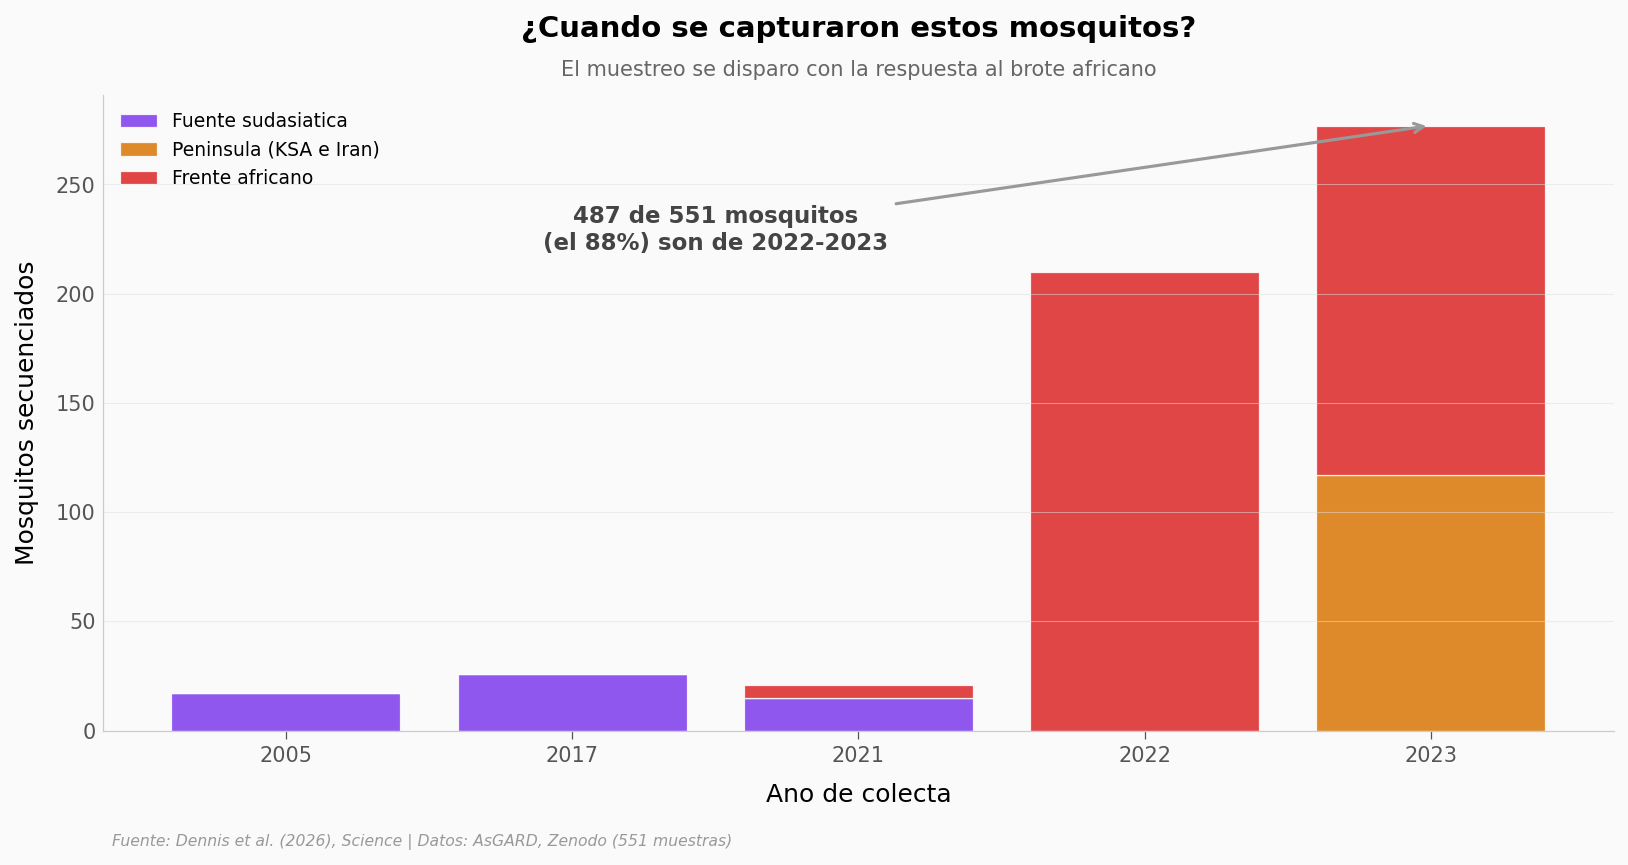

In [4]:
anios = sorted(df['anio'].dropna().unique().astype(int))
pivot = (df.dropna(subset=['anio'])
           .assign(anio=lambda d: d['anio'].astype(int))
           .groupby(['anio', 'SuperPopulation']).size()
           .unstack(fill_value=0)
           .reindex(columns=ORDEN_SUPER, fill_value=0))

fig, ax = plt.subplots(figsize=(13, 5.5))
abajo = np.zeros(len(pivot))
for sp in ORDEN_SUPER:
    ax.bar(pivot.index.astype(str), pivot[sp], bottom=abajo,
           color=COLOR_SUPER[sp], alpha=0.85, edgecolor='white',
           linewidth=0.6, label=ETIQUETA_SUPER[sp])
    abajo += pivot[sp].values

total_2223 = int(df[df['anio'] >= 2022].shape[0])
ax.annotate(f'{total_2223} de 551 mosquitos\n(el 88%) son de 2022-2023',
            xy=(str(2023), 277), xytext=(1.5, 220),
            fontsize=11, fontweight='bold', color='#444444', ha='center',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.5))

ax.set_title('¿Cuando se capturaron estos mosquitos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El muestreo se disparo con la respuesta al brote africano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ano de colecta')
ax.set_ylabel('Mosquitos secuenciados')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/linea_tiempo.png', dpi=200, bbox_inches='tight')
plt.show()

## La huella geográfica más limpia

Los años dicen *cuándo miramos*. La geografía dice algo más profundo. Si a cada mosquito le miramos solo su longitud —qué tan al este o al oeste estaba— el gradiente aparece solo: la fuente asiática a un extremo, el frente africano al otro. Ese salto de este a oeste es lo que la reconstrucción del paper lee como el sentido de la invasión.

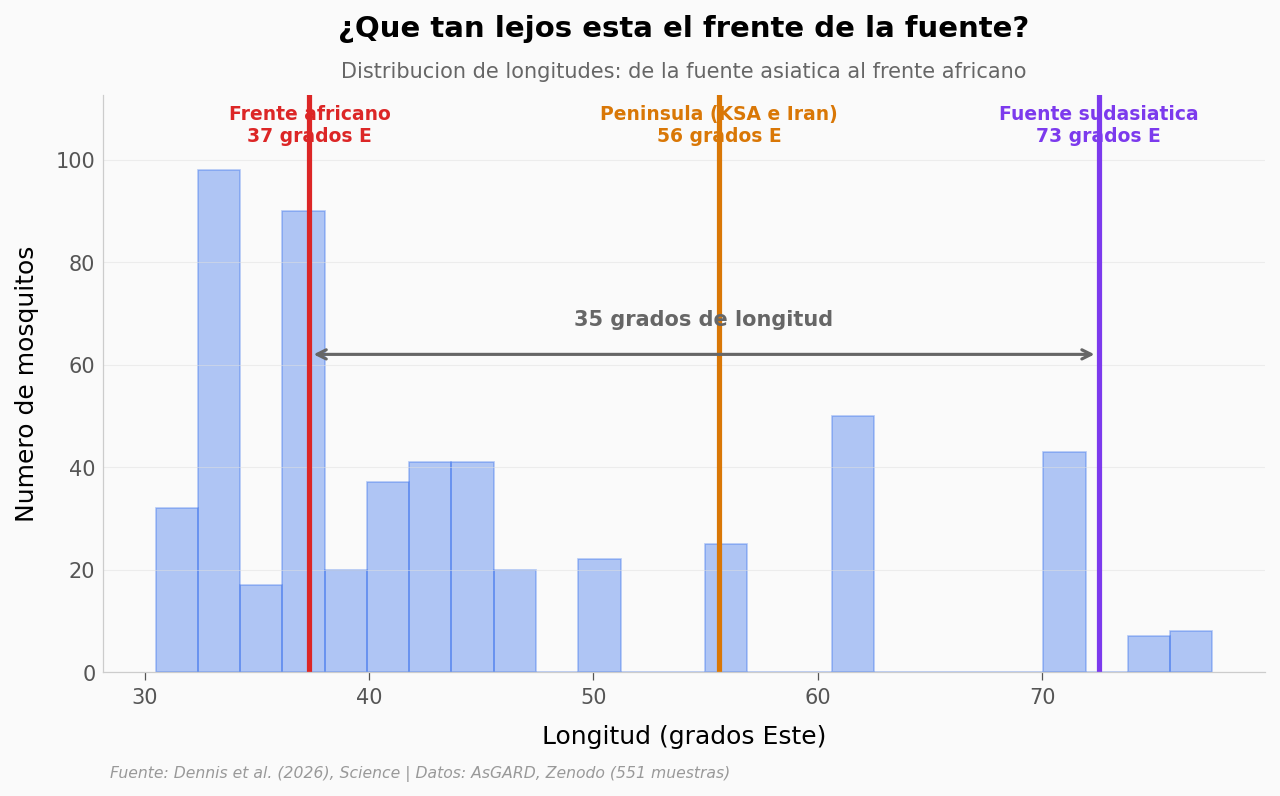

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

lon = df['longitude'].dropna()
n, bins, patches = ax.hist(lon, bins=25, color='#2563EB', alpha=0.35,
                           edgecolor='#2563EB', linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Centroides de longitud por super-poblacion
centroides = {sp: df.loc[df.SuperPopulation == sp, 'longitude'].mean()
              for sp in ORDEN_SUPER}
for sp in ORDEN_SUPER:
    c = centroides[sp]
    ax.axvline(x=c, color=COLOR_SUPER[sp], linewidth=2.5)
    ax.text(c, y_max * 0.92, f'{ETIQUETA_SUPER[sp]}\n{c:.0f} grados E',
            color=COLOR_SUPER[sp], fontsize=9, fontweight='bold', ha='center')

# Flecha del recorrido este -> oeste entre los extremos
ax.annotate('', xy=(centroides['Horn of Africa & Yemen'], y_max * 0.55),
            xytext=(centroides['Asia'], y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
salto = centroides['Asia'] - centroides['Horn of Africa & Yemen']
ax.text((centroides['Asia'] + centroides['Horn of Africa & Yemen']) / 2,
        y_max * 0.60, f'{salto:.0f} grados de longitud',
        color='#666666', fontsize=10, fontweight='bold', ha='center')

ax.set_title('¿Que tan lejos esta el frente de la fuente?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribucion de longitudes: de la fuente asiatica al frente africano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud (grados Este)')
ax.set_ylabel('Numero de mosquitos')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gradiente_longitud.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 551 mosquitos muestreados en 9 países | ✅ | Conteo directo de la tabla; 475 pasaron control de calidad |
| Tres super-poblaciones: fuente asiática, Península, frente africano | ✅ | 58 / 117 / 376 mosquitos respectivamente |
| Gradiente de longitud de este a oeste (72,5 → 55,6 → 37,3 °E) | ✅ | Centroides calculados sobre las coordenadas de captura |
| El 88% del muestreo es de 2022-2023 | ✅ | 487 de 551 mosquitos; refleja la respuesta al brote, no la fecha de la invasión |
| Yibuti fue la cabeza de puente de la invasión | ⚠️ | Es una **reconstrucción genómica del paper**, no algo que se derive de nuestra tabla de coordenadas |
| La ruta sur de Asia → Yibuti → frentes | ⚠️ | Inferida del ADN (paper); el abstract la enmarca como "*supports an invasion scenario*" |
| Frecuencias de resistencia a insecticidas | ❌ | No reproducible: requiere genotipos (VCF/zarr) embargados en ENA/MalariaGEN |

> **Limitaciones:** nuestra tabla es el **metadato de muestreo**, no el ADN. Reproduce la geografía y la composición del muestreo, no la genética de poblaciones (Fst, admixture) ni las frecuencias de resistencia del paper. El número de mosquitos por región refleja el **esfuerzo de vigilancia**, no la densidad real del mosquito. Y el muestreo concentrado en 2022-2023 no es una serie histórica: es la foto de cuando el mundo empezó a mirar.

## Ahora tú

1. **¿Y si separas por método de captura?** La columna `collection_method` distingue larvas de adultos. ¿Cambia el mapa si filtras `df[df.collection_method == 'larvae']`?
2. **¿Qué tan compacto es cada frente?** Prueba calcular la desviación estándar de longitud por super-población. ¿Cuál está más disperso geográficamente?
3. **¿El gradiente aguanta con la latitud?** Repite el histograma final usando `latitude` en vez de `longitude`. ¿Sigue contando la misma historia?

In [6]:
# --- EXPERIMENTA AQUI ---
# Que tan disperso esta cada grupo? Desviacion estandar de longitud por super-poblacion.
dispersion = (df.groupby('SuperPopulation')['longitude']
                .agg(['mean', 'std', 'count'])
                .reindex(ORDEN_SUPER)
                .round(1))
dispersion.columns = ['centroide_E', 'dispersion_std', 'n']
print(dispersion)
print()
print('Mas disperso ->', dispersion['dispersion_std'].idxmax(),
      f"({dispersion['dispersion_std'].max()} grados)")

                        centroide_E  dispersion_std    n
SuperPopulation                                         
Asia                           72.5             2.4   58
KSA & Iran                     55.6             6.0  117
Horn of Africa & Yemen         37.3             4.4  376

Mas disperso -> KSA & Iran (6.0 grados)


## Fuentes

**Paper**: [The origin, history, and resistance architecture of an invasive urban malaria mosquito in Africa](https://doi.org/10.1126/science.adx6925)  
*Science, 2026-07-09*

**Dataset canónico**: [Anopheles stephensi genomics and resistance diagnostics (AsGARD) v1 — Dennis 2026](https://doi.org/10.5281/zenodo.19324618)  
*Zenodo — 551 muestras de metadata; genotipos crudos embargados en ENA/MalariaGEN*

*19 afirmaciones del notebook verificadas contra estas fuentes*